# Prática - Mundo Pequeno
---

**Dupla:**

* Diane Fenzi Gonçalves (2019006574)
* Rubia Alice Moreira de Souza (2022043507)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

## Criar Rede de Mundo Pequeno
---

Inicialmente, devemos criar o grafo para a rede. Abaixo temos algumas funções que implementam a criação do grafo.

### Adicionar vertices no grafo
---

Primeiro, adicionamos os vértices no grafo.

In [ ]:
def adicionarVertices(tamanhoRede: int):
  redeMundoPequeno = nx.Graph()
  redeMundoPequeno.add_nodes_from(range(tamanhoRede))

  return redeMundoPequeno

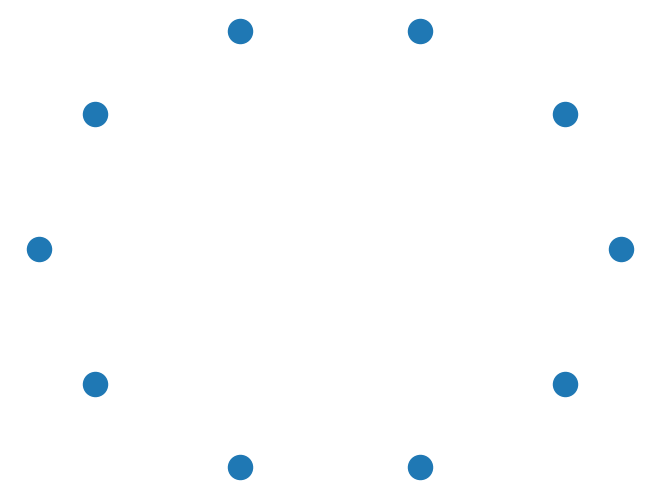

In [ ]:
def testarAdicionarVertices():
  rede = adicionarVertices(10)
  nx.draw_circular(rede)

testarAdicionarVertices()

### Adicionar arestas curtas
---

Depois adicionamos as arestas curtas fazendo o tratamento de borda. Com isso os vértices são conectados aos seus vizinhos mais próximos a esquerda e a direita.

In [ ]:
def adicionarArestasCurtas(
    grafo,
    quantidadeArestasCurtas: int
  ):
  i = 0
  nodes = list(grafo.nodes())
  quantidadeVertices = len(nodes)
  distanciaArestaCurta = int(quantidadeArestasCurtas / 2)

  for node in nodes:
    for j in range(1, distanciaArestaCurta + 1):
      indiceVizinho = (i + j) % quantidadeVertices
      indiceAntecessor = (i - j) % quantidadeVertices

      grafo.add_edge(node, indiceVizinho)
      grafo.add_edge(node, indiceAntecessor)
    i += 1

  return grafo

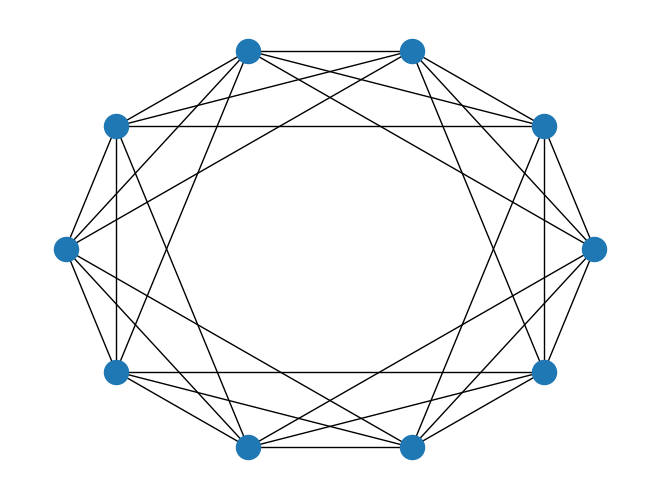

In [ ]:
def testarAdicionarArestasCurtas():
  rede = adicionarVertices(10)
  rede = adicionarArestasCurtas(rede, 6)
  nx.draw_circular(rede)

testarAdicionarArestasCurtas()

### Adicionar atalhos aleatórios
---

Por fim, devemos adicionar as arestas longas. Para isso, geramos dois números aleatórios que serão os vértices que vão ser conectados. Nós garantimos também que não é adicionada uma aresta de um vértice para ele mesmo.

In [ ]:
def adicionarArestasAtalhos(
    grafo,
    quantidadeArestasCurtas: int,
    probabilidade: float
  ):

  quantidadeVertices = len(grafo.nodes())
  quantidadeArestasAtalho = int(
    probabilidade * quantidadeVertices * (quantidadeArestasCurtas // 2)
  )

  for i in range(int(quantidadeArestasAtalho)):
    node1 = np.random.randint(0, quantidadeVertices)
    node2 = np.random.randint(0, quantidadeVertices)

    if node1 != node2:
      grafo.add_edge(node1, node2)

  return grafo

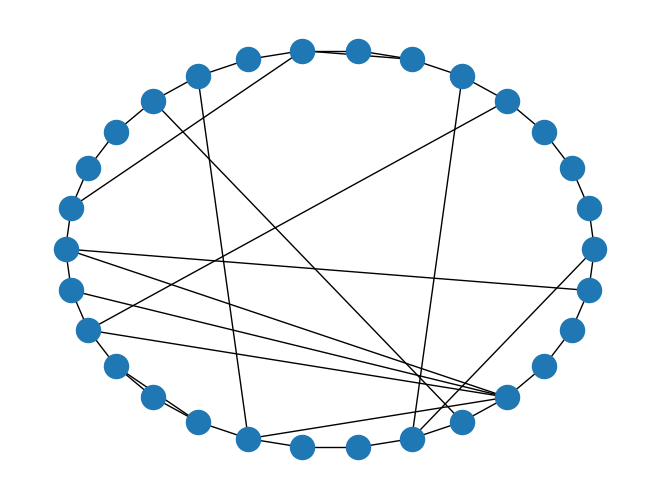

In [ ]:
def testarAdicionarArestasAtalhos():
  rede = adicionarVertices(30)
  rede = adicionarArestasCurtas(rede, 2)
  rede = adicionarArestasAtalhos(rede, 2, 0.5)
  nx.draw_circular(rede)

testarAdicionarArestasAtalhos()

### Criar a rede de mundo pequeno
---

Com todas essas etapas separadas implementadas e funcionando, podemos agora unificá-las para criar a rede de mundo pequeno da seguinte forma:

In [ ]:
def criarRedeMundoPequeno(
    quantidadeVertices: int,
    quantidadeArestasCurtas: int,
    probabilidade: float
  ):

  rede = adicionarVertices(quantidadeVertices)
  rede = adicionarArestasCurtas(rede, quantidadeArestasCurtas)
  rede = adicionarArestasAtalhos(rede, quantidadeArestasCurtas, probabilidade)

  return rede

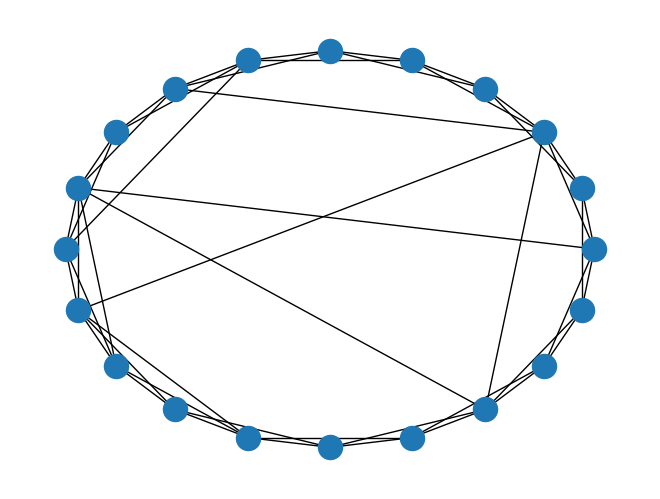

In [ ]:
def testarCriarRedeMundoPequeno():
  rede = criarRedeMundoPequeno(
    quantidadeVertices = 20,
    quantidadeArestasCurtas = 4,
    probabilidade = 0.2
  )

  nx.draw_circular(rede)

testarCriarRedeMundoPequeno()

Acima temos um exemplo de rede de mundo pequeno gerada com 20 vértices, sendo que cada um deles é conectado aos 4 vizinhos mais próximos por arestas curtas e há uma probabilidade de 0.2 de estabelecer uma aresta longa.

## Medindo as distâncias mínimas entre nós
---

Agora temos que implementar 3 funções:
* FindPathLengthsFromNode(): Para isso podemos utilizar uma BFS que fará uma busca no gráfo retornando a distância de cada um dos vértices a partir de um ponto de origem.

* FindAllPathLengths(): Depois de conseguir gerar a distância de todos os vértices para um ponto de origem, podemos calculá-la para todos os vértices. Assim, teremos uma matríz simétrica com a distância de um vértice qualquer para qualquer outro. Nos podemos pegar parte dasse matríz para gerar as distâncias de todos os caminhos.

* FindAveragePathLength(): Por fim, uma vez que temos as distâncias de todos os caminhos, podemos calcular a média deles.

### Parte 1
---

A seguir temos a implementação para encotrar a menor distância de um vértice para todos os outros.

In [ ]:
def FindPathLengthsFromNode(graph, node: int):
  layers: dict = dict(enumerate(nx.bfs_layers(graph, node)))
  quantidadeNodes: int = len(graph.nodes())
  distancias = np.zeros(quantidadeNodes)

  for key, value in layers.items():
    distancias[value] = key

  return distancias

Distância de 0 para 0: 0.0
Distância de 0 para 1: 1.0
Distância de 0 para 2: 2.0
Distância de 0 para 3: 2.0
Distância de 0 para 4: 1.0
Distância de 0 para 5: 2.0
Distância de 0 para 6: 3.0
Distância de 0 para 7: 3.0
Distância de 0 para 8: 2.0
Distância de 0 para 9: 1.0


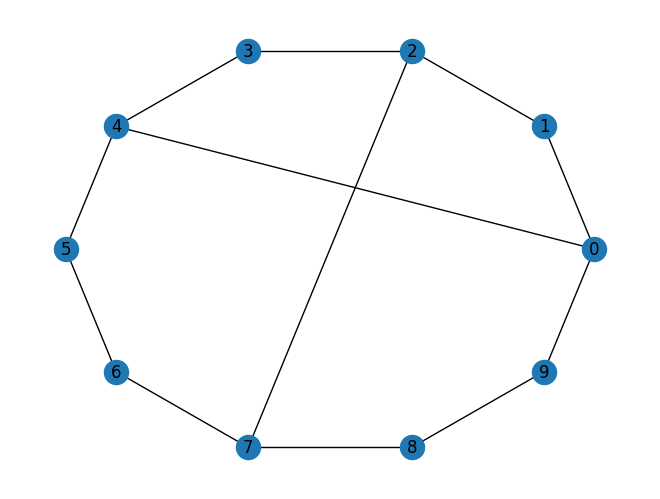

In [ ]:
def testarFindPathLengthsFromNode():
  rede = criarRedeMundoPequeno(
    quantidadeVertices = 10,
    quantidadeArestasCurtas = 2,
    probabilidade = 0.5
  )

  nx.draw_circular(rede, with_labels = True)
  distancias = FindPathLengthsFromNode(rede, 0)
  for i in range(len(distancias)):
    print(f"Distância de 0 para {i}: {distancias[i]}")

testarFindPathLengthsFromNode()

### Parte 2
---

Agora podemos calcular essas distâncias para todos os vértices gerando uma matriz e então selecionar parte dela com todas as distâncias. Abaixo nós geramos a matriz simétrica:

In [ ]:
def FindAllPathLengthsCompleto(graph):
  quantidadeNodes = len(graph.nodes())
  distancias: list = []

  for i in range(quantidadeNodes):
    distancias.append(FindPathLengthsFromNode(graph, i))

  return distancias

In [ ]:
def testearFindAllPathLengthsCompleto():
  rede = criarRedeMundoPequeno(
    quantidadeVertices = 10,
    quantidadeArestasCurtas = 2,
    probabilidade = 0.5
  )
  distancias = FindAllPathLengthsCompleto(rede)
  return distancias

testearFindAllPathLengthsCompleto()

[array([0., 1., 2., 3., 4., 3., 2., 3., 2., 1.]),
 array([1., 0., 1., 2., 3., 4., 3., 3., 3., 2.]),
 array([2., 1., 0., 1., 2., 3., 2., 2., 2., 1.]),
 array([3., 2., 1., 0., 1., 2., 2., 1., 2., 2.]),
 array([4., 3., 2., 1., 0., 1., 2., 2., 3., 3.]),
 array([3., 4., 3., 2., 1., 0., 1., 2., 3., 2.]),
 array([2., 3., 2., 2., 2., 1., 0., 1., 2., 1.]),
 array([3., 3., 2., 1., 2., 2., 1., 0., 1., 2.]),
 array([2., 3., 2., 2., 3., 3., 2., 1., 0., 1.]),
 array([1., 2., 1., 2., 3., 2., 1., 2., 1., 0.])]

Abaixo temos a função final que filtra as distâncias a partir da diagonal da matriz.

In [ ]:
def FindAllPathLengths(graph):
  quantidadeNodes = len(graph.nodes())
  distancias: list = FindAllPathLengthsCompleto(graph)

  distanciasUnicas = []
  for i in range(len(distancias)):
    for j in range(i + 1, len(distancias[i])):
      distanciasUnicas.append(distancias[i][j])

  return distanciasUnicas

In [ ]:
def plotHistograma(todasDistancias):
  legenda = []

  plt.hist(todasDistancias, edgecolor = 'black')

  plt.xlabel('Distância')
  plt.ylabel('Frequências')
  plt.show()

In [ ]:
def plotFindAllPathLengths(
    quantidadeVertices: int,
    quantidadeArestasCurtas: int,
    probabilidade: float
  ):

  rede = criarRedeMundoPequeno(
    quantidadeVertices = quantidadeVertices,
    quantidadeArestasCurtas = quantidadeArestasCurtas,
    probabilidade = probabilidade
  )

  todasDistancias = FindAllPathLengths(rede)
  plotHistograma(todasDistancias)

In [ ]:
def plotHistogramaDistanciasCompleto(
    rede
):
  todasDistancias = FindAllPathLengthsCompleto(rede)
  plt.hist(todasDistancias, edgecolor = 'black', density = False)
  plt.title("Histograma das distâncias separadas por vértice")
  plt.xlabel('Distância')
  plt.ylabel('Frequências')
  plt.show()

In [ ]:
def plotHistogramaDistanciasPorVertice(
    quantidadeVertices: int,
    quantidadeArestasCurtas: int,
    probabilidade: float
):
  rede = criarRedeMundoPequeno(
    quantidadeVertices = quantidadeVertices,
    quantidadeArestasCurtas = quantidadeArestasCurtas,
    probabilidade = probabilidade
  )

  nx.draw_circular(rede, with_labels = True)
  plt.show()

  todasDistancias = FindAllPathLengths(rede)
  bins = range(int(max(todasDistancias)) + 2)
  plt.hist(todasDistancias, bins = bins, edgecolor = 'black', density = False)
  plt.xlim(1, quantidadeVertices // quantidadeArestasCurtas)
  plt.title("Histograma de todas as distâncias")
  plt.xlabel('Distância')
  plt.ylabel('Frequências')
  plt.show()

  plotHistogramaDistanciasCompleto(rede)

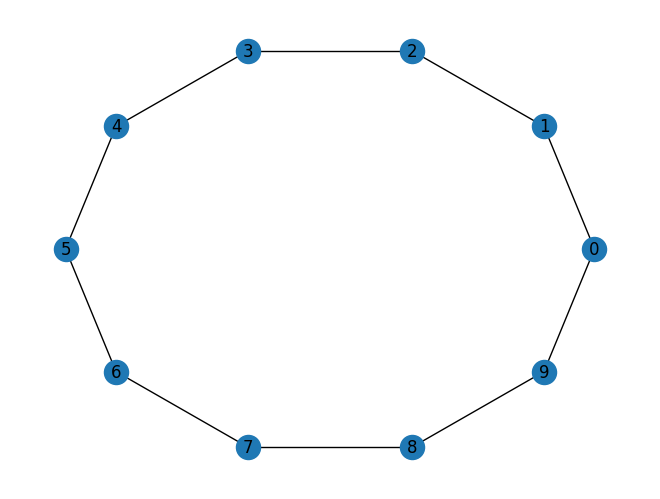

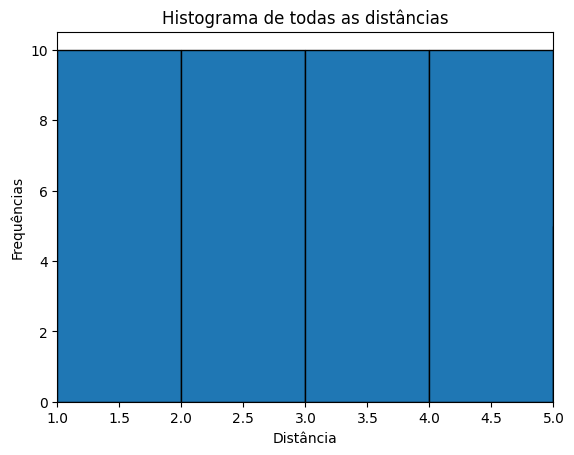

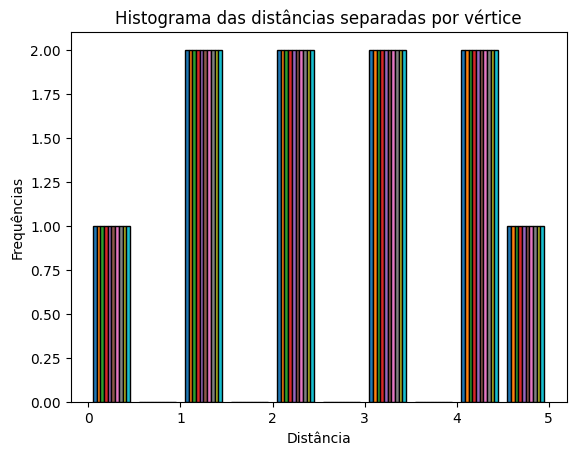

In [ ]:
plotHistogramaDistanciasPorVertice(
    quantidadeVertices = 10,
    quantidadeArestasCurtas = 2,
    probabilidade = 0
)

* É possível notar que as distâncias são uniformes para um grafo com probabilidade zero de estabelecer atalhos.
* Além disso, o plot das distâncias separadas por vértice demonstram que elas sempre estão entre os valores 0 e 5, que é esperado devido a característica do grafo, fazendo ser necessário percorrer alguns dos arcos do círculo para chegar no vértice desejado.
* Portanto, conforme o esperado, as distâncias são saltos de comprimento Z/2 e não temos caminhos de comprimento maior N/Z (neste caso, 5).

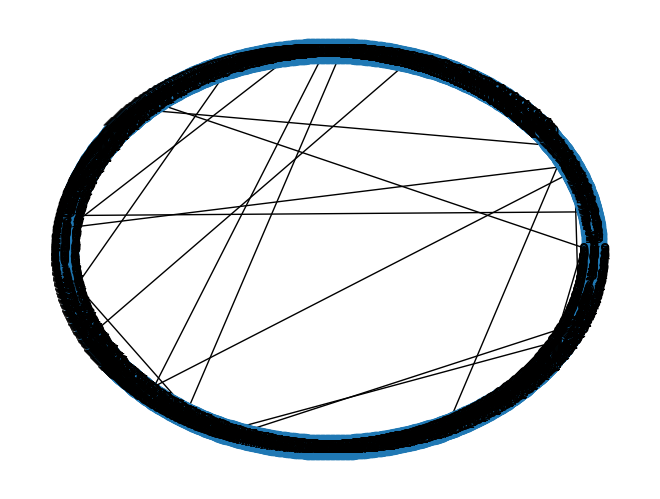

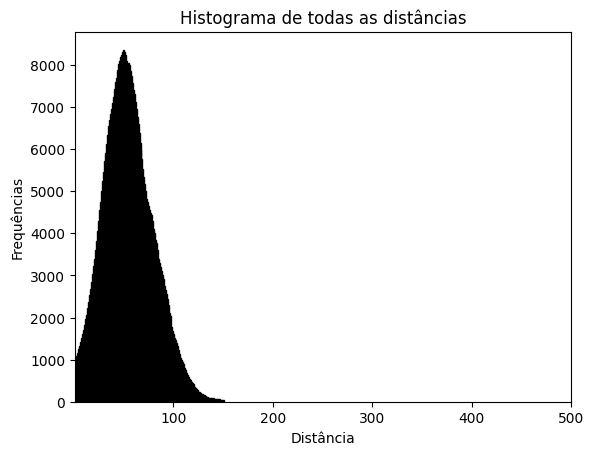

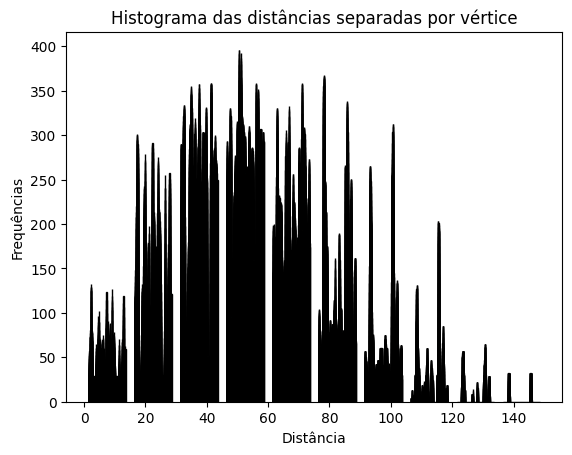

In [ ]:
plotHistogramaDistanciasPorVertice(
    quantidadeVertices = 1000,
    quantidadeArestasCurtas = 2,
    probabilidade = 0.02
)

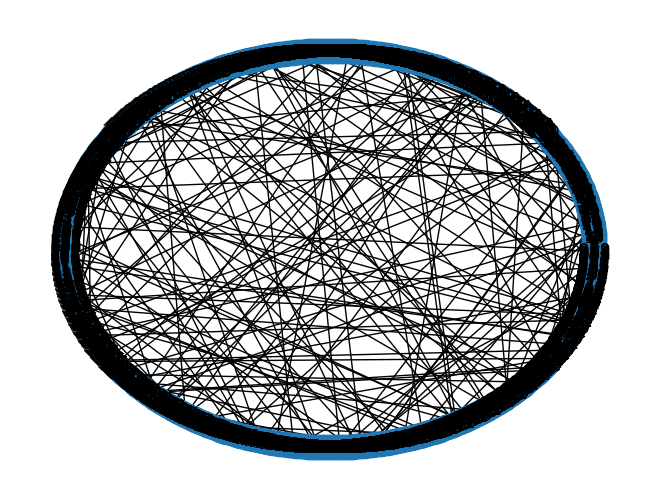

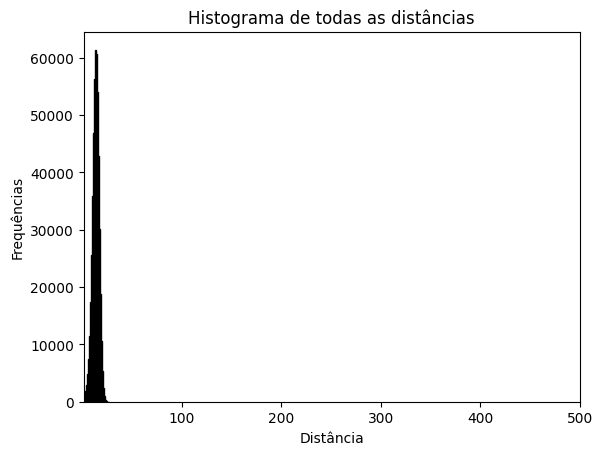

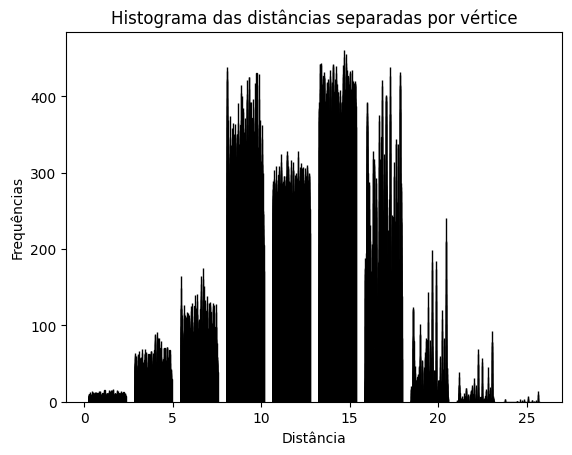

In [ ]:
plotHistogramaDistanciasPorVertice(
    quantidadeVertices = 1000,
    quantidadeArestasCurtas = 2,
    probabilidade = 0.2
)

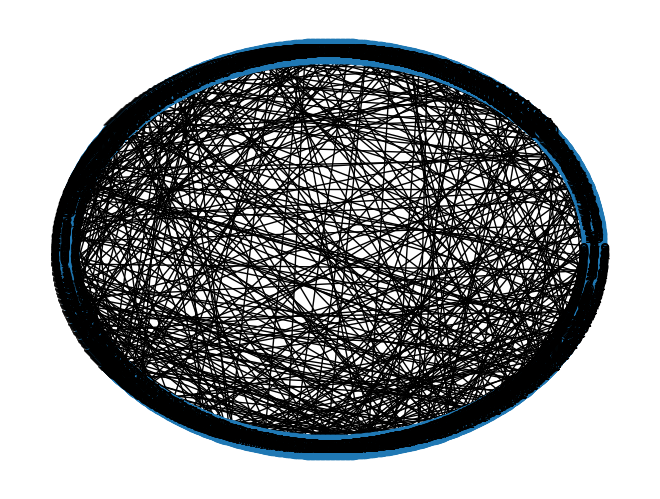

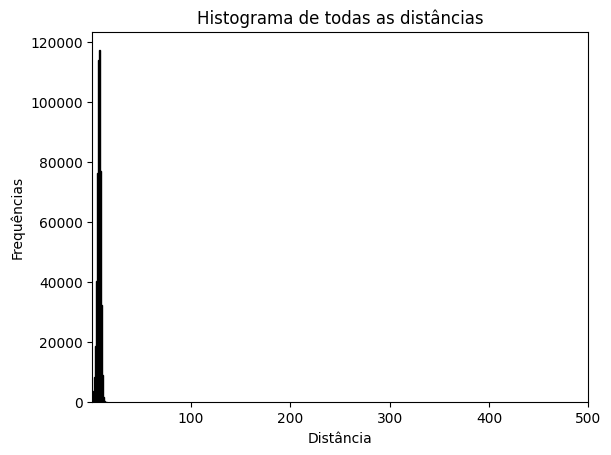

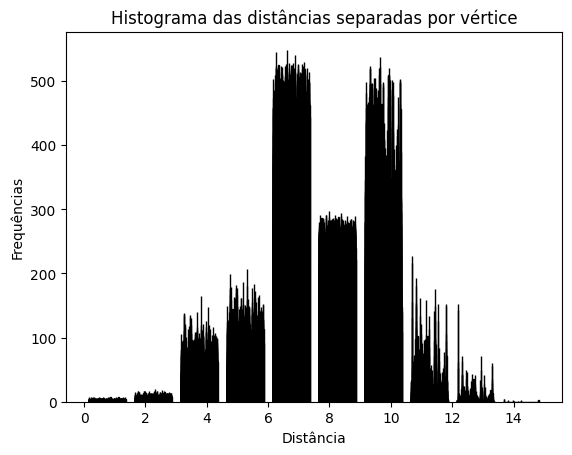

In [ ]:
plotHistogramaDistanciasPorVertice(
    quantidadeVertices = 1000,
    quantidadeArestasCurtas = 2,
    probabilidade = 0.5
)

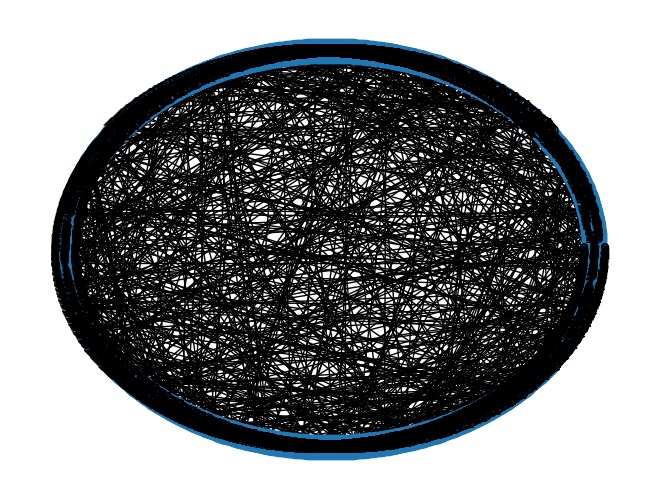

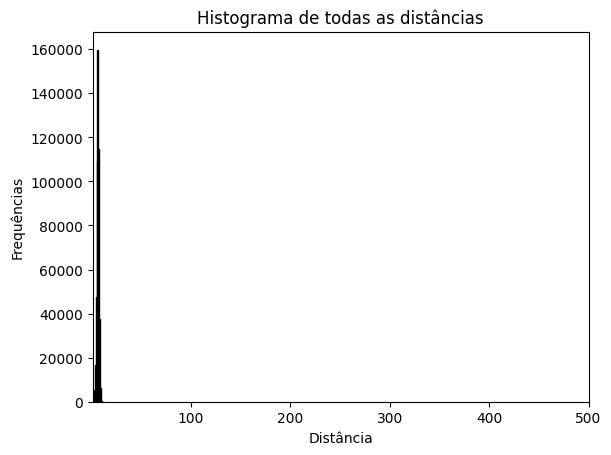

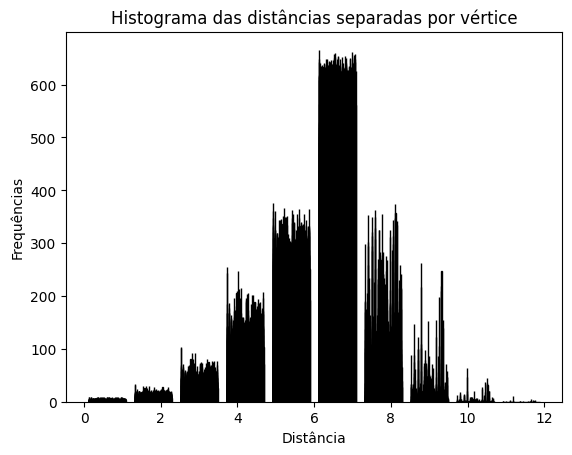

In [ ]:
plotHistogramaDistanciasPorVertice(
    quantidadeVertices = 1000,
    quantidadeArestasCurtas = 2,
    probabilidade = 0.8
)

* Primeiramente, a medida que aumentamos o valor de "p", aumentamos a chance de haver mais arestas longas no grafo. Isso reflete diretamente na distância dos caminhos, como apontado pelo histograma. A medida que "p" aumenta, o histograma se desloca para esquerda, se aproximando de distâncias cada vez menores. Além disso, sua média também vai reduzindo ao longo do tempo.

* Ao chegar no valor de "p = 0.8" conseguimos chegar ao ponto dos 6 graus de separação para o grafo com 1000 vértices e 2 arestas curtas por vértice.

In [ ]:
def sobreporSomaDistanciasPorVertice():
  probabilidades = [0.02, 0.2, 0.5, 0.8, 1]
  quantidadeVertices = 1000
  quantidadeArestasCurtas = 2

  somasDistancias = []

  for probabilidade in probabilidades:
    rede = criarRedeMundoPequeno(
      quantidadeVertices = quantidadeVertices,
      quantidadeArestasCurtas = quantidadeArestasCurtas,
      probabilidade = probabilidade
    )

    todasDistancias = FindAllPathLengthsCompleto(rede)
    somaDistancias = np.sum(todasDistancias, axis = 0)
    somasDistancias.append(somaDistancias)

  i = 0
  legendas = []
  for somaDistancia in somasDistancias:
    plt.hist(somaDistancia, edgecolor = 'black', alpha = 0.5)
    legendas.append(f"Probabilidade: {probabilidades[i]}")
    i += 1

  plt.legend(legendas)
  plt.xlabel('Distância')
  plt.ylabel('Frequências')
  plt.show()

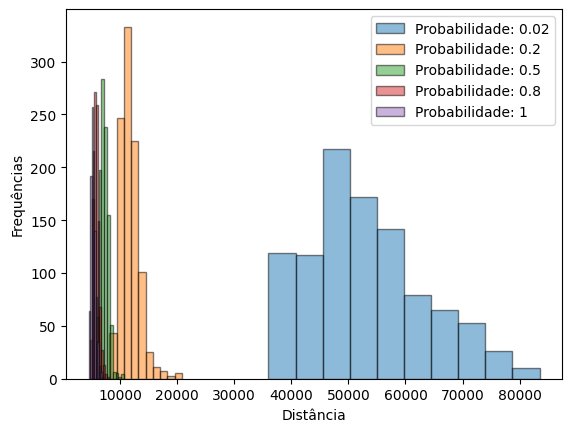

In [ ]:
sobreporSomaDistanciasPorVertice()

### Parte 3
---

In [ ]:
def FindAveragePathLength(graph):
  todasDistancias = FindAllPathLengths(graph)
  return np.mean(todasDistancias)

In [ ]:
def calcularMediasDistanciasPorVertice(
    quantidadeVertices: int,
    quantidadeArestasCurtas: int,
    probabilidade: float,
    quantidadeTestes: int
):

  qtdArestasLongas = (
    probabilidade * quantidadeVertices * quantidadeArestasCurtas / 2
  )

  for i in range(quantidadeTestes):
    rede = criarRedeMundoPequeno(
      quantidadeVertices = quantidadeVertices,
      quantidadeArestasCurtas = quantidadeArestasCurtas,
      probabilidade = probabilidade
    )
    mediaDistancias = FindAveragePathLength(rede)
    print(f"Médias caminho: {mediaDistancias}")

  print(f"Quantidade aproximada de arestas longas: {qtdArestasLongas}")

In [ ]:
calcularMediasDistanciasPorVertice(
  quantidadeVertices = 100,
  quantidadeArestasCurtas = 2,
  probabilidade = 0.1,
  quantidadeTestes = 10
)

Médias caminho: 9.216969696969697
Médias caminho: 10.031717171717172
Médias caminho: 8.407070707070707
Médias caminho: 10.248484848484848
Médias caminho: 9.445858585858586
Médias caminho: 9.08868686868687
Médias caminho: 10.956969696969697
Médias caminho: 10.421616161616162
Médias caminho: 11.181414141414141
Médias caminho: 10.786262626262626
Quantidade aproximada de arestas longas: 10.0


* É possível notar que obtevemos um valor médio de "d" próximo do proposto de 10
* Também é possível notar que houveram diversas variações nas médias para cada novo grafo gerado
* A aleatoriedade é esperada, pois os caminhos são adicionados aleatóriamente. Assim, a posição onde ele são alocados interfere diretamente com a distância média.

In [ ]:
def plotSemilogValoresProbabilidade():
  redeZero = criarRedeMundoPequeno(
    quantidadeVertices = 50,
    quantidadeArestasCurtas = 2,
    probabilidade = 0
  )
  mediaRedeZero = FindAveragePathLength(redeZero)
  print(f"Média caminho rede zero: {mediaRedeZero}")

  valoresProbabilidade = np.logspace(-3, 3, num = 20)
  proporcoes = []

  for probabilidade in valoresProbabilidade:
    rede = criarRedeMundoPequeno(
      quantidadeVertices = 50,
      quantidadeArestasCurtas = 2,
      probabilidade = probabilidade
    )
    mediaRede = FindAveragePathLength(rede)
    proporcoes.append(mediaRede / mediaRedeZero)

  plt.semilogx(valoresProbabilidade, proporcoes, marker = 'o')
  plt.xlabel('Probabilidade')
  plt.ylabel('Proporção')
  plt.show()

Média caminho rede zero: 12.755102040816327


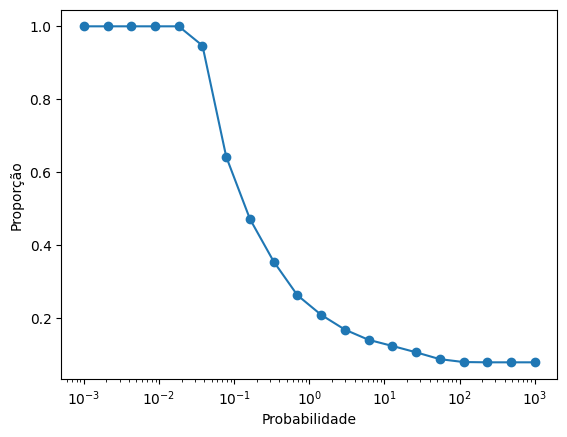

In [ ]:
plotSemilogValoresProbabilidade()

**Por que o gráfico é fixado em um para 𝑝 pequeno?**

## Grande 𝑵 e a emergência de um limite contínuo
---

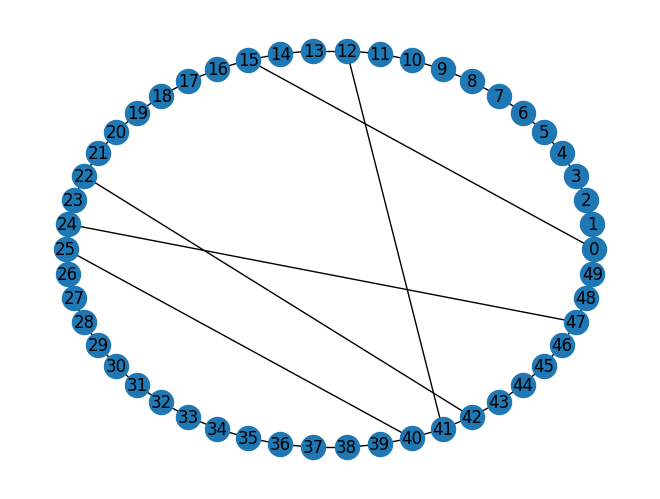

In [ ]:
rede = criarRedeMundoPequeno(
    quantidadeVertices = 50,
    quantidadeArestasCurtas = 2,
    probabilidade = 0.1
)

nx.draw_circular(rede, with_labels = True)

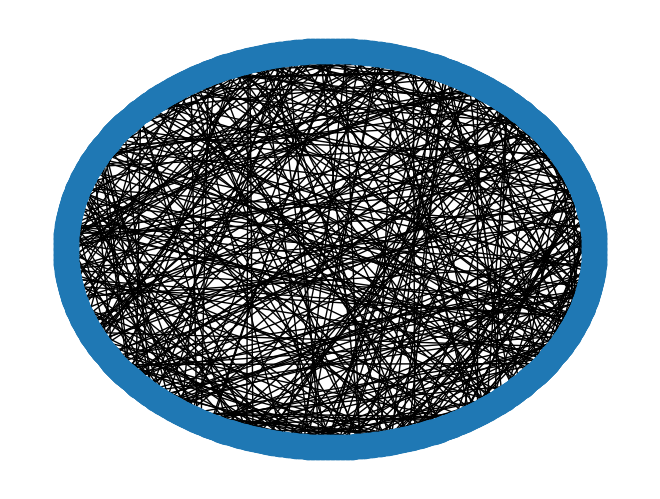

In [ ]:
rede = nx.watts_strogatz_graph(1000, 10, 0.1)
nx.draw_circular(rede)

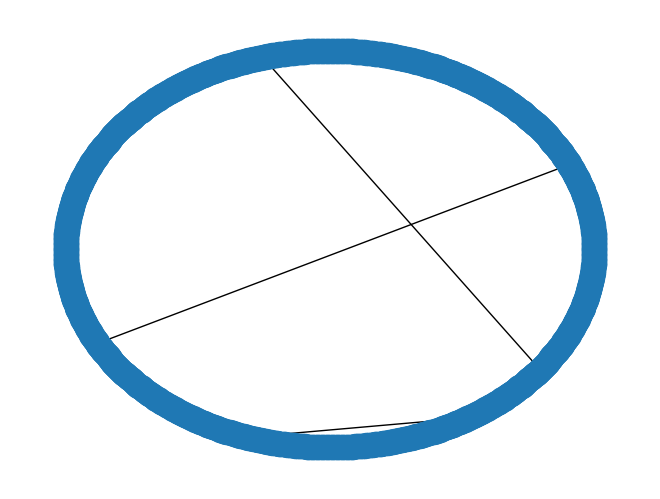

In [ ]:
rede = nx.watts_strogatz_graph(1000, 10, 0.001)
nx.draw_circular(rede)

Entre as duas redes de Watts e Strogatz, é possível notar que a segunda é a que se aproxima mais da rede gerada por nós com os parâmetros de:

* quantidadeVertices = 50,
* quantidadeArestasCurtas = 2,
* probabilidade = 0.1

### Plote do comprimento médio do caminho redimensionado pelo total de atalhos
---

In [ ]:
def calcularComprimentoMedioCaminhoRedimensionado(
    quantidadeVertices: int,
    quantidadeArestasCurtas: int,
    averagePathLength: float,
):
  return (
    np.pi * quantidadeArestasCurtas * averagePathLength / quantidadeVertices
  )

In [ ]:
def calcularQuantidadeArestasLongas(
    quantidadeVertices: int,
    quantidadeArestasCurtas: int,
    probabilidade: float,
):

  return (
    probabilidade * quantidadeVertices * (quantidadeArestasCurtas / 2)
  )

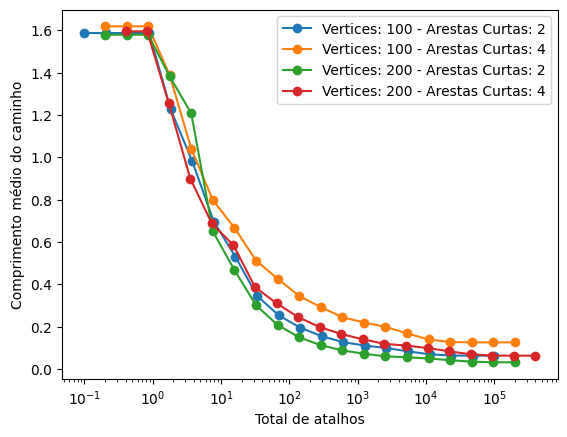

In [ ]:
valoresProbabilidade = np.logspace(-3, 3, 20)
estados = [(100, 2), (100, 4), (200, 2), (200, 4)]

for estado in estados:
  quantidadeVertices = estado[0]
  quantidadeArestasCurtas = estado[1]

  comprimentosMedios = []
  listaTotalAtalhos = []

  for probabilidade in valoresProbabilidade:
    rede = criarRedeMundoPequeno(
      quantidadeVertices = quantidadeVertices,
      quantidadeArestasCurtas = quantidadeArestasCurtas,
      probabilidade = probabilidade
    )
    mediaRede = FindAveragePathLength(rede)

    comprimentoMedio = calcularComprimentoMedioCaminhoRedimensionado(
      quantidadeVertices = quantidadeVertices,
      quantidadeArestasCurtas = quantidadeArestasCurtas,
      averagePathLength = mediaRede
    )

    totalAtalhos = calcularQuantidadeArestasLongas(
      quantidadeVertices = quantidadeVertices,
      quantidadeArestasCurtas = quantidadeArestasCurtas,
      probabilidade = probabilidade
    )

    comprimentosMedios.append(comprimentoMedio)
    listaTotalAtalhos.append(totalAtalhos)

  plt.semilogx(
    listaTotalAtalhos,
    comprimentosMedios,
    marker = 'o',
    label = f"Vertices: {quantidadeVertices} - Arestas Curtas: {quantidadeArestasCurtas}"
  )

plt.xlabel('Total de atalhos')
plt.ylabel('Comprimento médio do caminho')
plt.legend()
plt.show()

## Redes Reais - Ratinho
---

Para executar esta parte do notebook, é necessário baixar e extrair o arquivo .edges disponível neste link: https://networkrepository.com/bio-grid-mouse.php. Então, faça o upload do arquivo no ambiente do notebook sem alterar o nome dele.

In [ ]:
# Extrai as arestas com base na formatação arquivo .edge
def getArestasArquivo(nomeArquivo):
  with open(nomeArquivoRedeReal, 'r') as arquivo:
    arestas = [
      linha.strip().split(',') for linha in arquivo if not linha.startswith('%%')
    ]

    return arestas

In [ ]:
def criarGrafo(arestas):
  grafo = nx.Graph()
  grafo.add_edges_from((int(aresta[0]), int(aresta[1])) for aresta in arestas)

  if not nx.is_connected(grafo):
    maiorComponenteConexo = max(nx.connected_components(grafo), key = len)
    grafo = grafo.subgraph(maiorComponenteConexo).copy()

  return grafo

In [ ]:
def encontrarTodosComprimentos(grafo):
  nodes = list(grafo.nodes())
  # Gerar matriz completa
  dicionarioDistancias = dict(nx.all_pairs_shortest_path_length(grafo))
  quantidadeVertices = len(nodes)
  todasDistancias = []

  # Extrair matriz triangular
  for iNodes in range(quantidadeVertices):
    for jNodes in range(iNodes + 1, quantidadeVertices):
      i = nodes[iNodes]
      j = nodes[jNodes]
      todasDistancias.append(dicionarioDistancias[i][j])

  return todasDistancias

In [ ]:
def plotHistogramaRedeReal(nomeArquivoRede, titulo):
  arestas = getArestasArquivo(nomeArquivoRede)
  grafo = criarGrafo(arestas)
  distancias = encontrarTodosComprimentos(grafo)

  distanciaMedia = np.mean(distancias)
  print("Valor da distância média: ", distanciaMedia)

  bins = range(1, max(distancias))
  plt.hist(distancias, bins = bins, edgecolor = 'black')
  plt.title(titulo)
  plt.xlabel("Distância")
  plt.ylabel("Frequência")
  plt.show()

Valor da distância média:  8.663009489670182


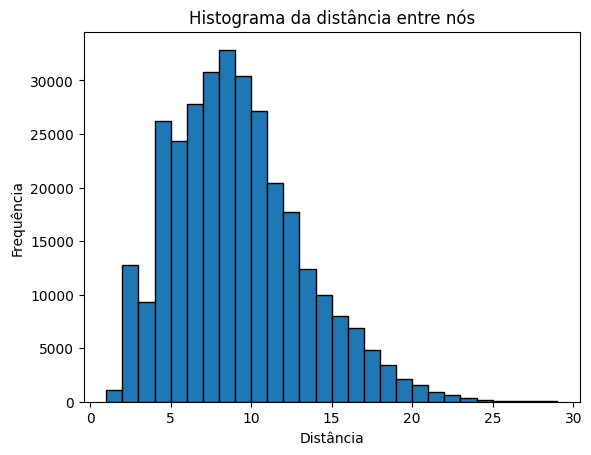

In [ ]:
nomeArquivoRedeReal = "bio-grid-mouse.edges"
plotHistogramaRedeReal(
  nomeArquivoRedeReal,
  "Histograma da distância entre nós"
)

* Novamente, encontramos um valor de distância média bem baixo, mesmo para uma rede bem complexa como a utilizada: "[grid-mouse](https://networkrepository.com/bio-grid-mouse.php)". Isso nos leva acreditar que a rede deve possuir uma probabilidade alta para os atalhos, uma vez que chegamos a média próxima dos seis graus de separação.